# Step 2 — Structural Penalty Φ_S (Calculations S1–S3)

**Purpose:** Quantify structural constraints acting on each V-gene position:
- **S1** — Position-specific selection pressure ω_i: empirical dN/dS per Aho position using S5F as the neutral expectation
- **S2** — Forbidden mutations: positions where SHM generates mutations that selection removes (high expected, low observed frequency)
- **S3** — VH/VL interface co-variation: mutual information between Vernier zone positions across all paired memory sequences

**Input:** `processed/aligned_master.parquet`, `processed/mutability_profiles.parquet`  
**Outputs:** `results/tables/omega_per_position.parquet`, `results/tables/forbidden_mutations.parquet`, `results/tables/vh_vl_mutual_information.csv`, `results/figures/`  
**Design reference:** DESIGN.md §Step 2 (S1–S3)

In [1]:
import polars as pl
import numpy as np
from pathlib import Path
from collections import defaultdict
import time

In [2]:
DATA_DIR  = Path("/home/jovyan/shared/Benjamin/LineageAtlas/pairplex_paper/")
PROC_DIR  = DATA_DIR / "processed"
RESULTS   = DATA_DIR / "results"
FIGURES   = RESULTS / "figures"
TABLES    = RESULTS / "tables"

MASTER_FILE      = PROC_DIR / "aligned_master.parquet"
MUTABILITY_FILE  = PROC_DIR / "mutability_profiles.parquet"
MUTATED_FILE     = PROC_DIR / "iggnition_sequences.parquet"
GERMLINE_FILE    = PROC_DIR / "iggnition_germlines.parquet"

OMEGA_FILE   = TABLES / "omega_per_position.parquet"
FORBID_FILE  = TABLES / "forbidden_mutations.parquet"
MI_FILE      = TABLES / "vh_vl_mutual_information.csv"

print("Paths OK")

Paths OK


In [3]:
master = pl.read_parquet(MASTER_FILE)
profile_H = pl.read_parquet(MUTABILITY_FILE)

memory = master.filter(~pl.col('naive_bio') & ~pl.col('naive_comp'))
KEY = "seq_name"
GAP = 45
INT_TO_NT = {65: 'A', 67: 'C', 71: 'G', 84: 'T'}

print(f"Master: {master.shape}")
print(f"Memory: {memory.height:,}")
print(f"Mutability profile: {profile_H.shape}")

Master: (4269981, 331)
Memory: 1,517,911
Mutability profile: (324, 12)


In [4]:
def aho_to_nt_cols(chain: str, aho_start: int, aho_end: int) -> list[str]:
    return [f"{chain}{i}" for i in range((aho_start - 1) * 3 + 1, aho_end * 3 + 1)]

H_REGIONS = {
    'FR1' : aho_to_nt_cols('H',   1,  25),
    'CDR1': aho_to_nt_cols('H',  26,  38),
    'FR2' : aho_to_nt_cols('H',  39,  49),
    'CDR2': aho_to_nt_cols('H',  50,  64),
    'FR3' : aho_to_nt_cols('H',  65, 108),
    'CDR3': aho_to_nt_cols('H', 109, 137),
    'FR4' : aho_to_nt_cols('H', 138, 149),
}
L_REGIONS = {
    'FR1' : aho_to_nt_cols('L',   1,  25),
    'CDR1': aho_to_nt_cols('L',  26,  38),
    'FR2' : aho_to_nt_cols('L',  39,  49),
    'CDR2': aho_to_nt_cols('L',  50,  66),
    'FR3' : aho_to_nt_cols('L',  67, 108),
    'CDR3': aho_to_nt_cols('L', 109, 138),
    'FR4' : aho_to_nt_cols('L', 139, 148),
}

H_CDR_V = H_REGIONS['CDR1'] + H_REGIONS['CDR2']
H_FWR_V = H_REGIONS['FR1']  + H_REGIONS['FR2'] + H_REGIONS['FR3']
H_ALL_V  = H_FWR_V + H_CDR_V

col_to_region_H = {}
for reg, cols in H_REGIONS.items():
    for c in cols:
        col_to_region_H[c] = reg

print(f"H V-gene: {len(H_ALL_V)//3} codons")

H V-gene: 108 codons


In [5]:
GENETIC_CODE = {
    'TTT':'F','TTC':'F','TTA':'L','TTG':'L','CTT':'L','CTC':'L','CTA':'L','CTG':'L',
    'ATT':'I','ATC':'I','ATA':'I','ATG':'M','GTT':'V','GTC':'V','GTA':'V','GTG':'V',
    'TCT':'S','TCC':'S','TCA':'S','TCG':'S','CCT':'P','CCC':'P','CCA':'P','CCG':'P',
    'ACT':'T','ACC':'T','ACA':'T','ACG':'T','GCT':'A','GCC':'A','GCA':'A','GCG':'A',
    'TAT':'Y','TAC':'Y','TAA':'*','TAG':'*','CAT':'H','CAC':'H','CAA':'Q','CAG':'Q',
    'AAT':'N','AAC':'N','AAA':'K','AAG':'K','GAT':'D','GAC':'D','GAA':'E','GAG':'E',
    'TGT':'C','TGC':'C','TGA':'*','TGG':'W','CGT':'R','CGC':'R','CGA':'R','CGG':'R',
    'AGT':'S','AGC':'S','AGA':'R','AGG':'R','GGT':'G','GGC':'G','GGA':'G','GGG':'G',
}
AA_LOOKUP = {0: 0}
for codon, aa in GENETIC_CODE.items():
    k = ord(codon[0]) * 65536 + ord(codon[1]) * 256 + ord(codon[2])
    AA_LOOKUP[k] = ord(aa)
_aa_vec = np.vectorize(lambda k: AA_LOOKUP.get(int(k), 0), otypes=[np.int32])

def translate_codon_array(nt):
    keys = nt[:, 0].astype(np.int32) * 65536 + nt[:, 1].astype(np.int32) * 256 + nt[:, 2].astype(np.int32)
    return _aa_vec(keys)

# Pre-compute expected R and S fractions for every codon string
# E[dN_frac]: fraction of single-nt changes from this codon that are replacement
# E[dS_frac]: fraction that are synonymous
# Used as the neutral expectation for dN/dS under uniform mutability
NT_LIST = list('ACGT')

def expected_rs_fractions(codon: str) -> tuple[float, float]:
    """Return (E_dN_frac, E_dS_frac) for a codon under uniform single-nt substitution."""
    ref_aa = GENETIC_CODE.get(codon, None)
    if ref_aa is None:
        return (np.nan, np.nan)
    n_R, n_S, n_total = 0, 0, 0
    for pos in range(3):
        for nt in NT_LIST:
            if nt == codon[pos]:
                continue
            mut = codon[:pos] + nt + codon[pos+1:]
            mut_aa = GENETIC_CODE.get(mut, None)
            if mut_aa is None:
                continue
            if mut_aa == '*' or ref_aa == '*':
                continue
            n_total += 1
            if mut_aa != ref_aa:
                n_R += 1
            else:
                n_S += 1
    if n_total == 0:
        return (np.nan, np.nan)
    return n_R / n_total, n_S / n_total

print("Genetic code and neutral expectations loaded.")

Genetic code and neutral expectations loaded.


## S1 — Position-specific ω_i (dN/dS per Aho position)

For each Aho AA position i, across all memory sequences:
- `dN_obs(i)`: fraction of sequences with a replacement mutation at position i
- `dS_obs(i)`: fraction with a silent mutation at position i
- `E[dN(i)]`, `E[dS(i)]`: expected under neutral evolution (S5F mutability × codon structure)
- `ω_i = (dN_obs / E[dN]) / (dS_obs / E[dS])`

ω < 1 → purifying selection (structural constraint → Φ_S contributor)  
ω > 1 → positive selection (affinity-driven → Φ_A contributor)

In [6]:
print("Loading alignment tables...")
mutated  = pl.read_parquet(MUTATED_FILE)
germline = pl.read_parquet(GERMLINE_FILE)

mutated_dedup  = mutated.unique(subset=[KEY], keep='first')
germline_dedup = germline.unique(subset=[KEY], keep='first')

# Memory sequences only
memory_names = set(memory[KEY].to_list())
mut_mem  = mutated_dedup.filter(pl.col(KEY).is_in(memory_names))
germ_mem = germline_dedup.filter(pl.col(KEY).is_in(memory_names))

# Build aligned joint for memory sequences
pos_cols = [c for c in mutated.columns if c != KEY]
aligned_mem = mut_mem.join(germ_mem, on=KEY, how='inner', suffix='_germ').sort(KEY)
print(f"Memory aligned joint: {aligned_mem.height:,}")

# H V-region arrays
H_V_COLS_SEQ  = [c for c in H_ALL_V if c in set(aligned_mem.columns) and f"{c}_germ" in set(aligned_mem.columns)]
H_V_COLS_GERM = [f"{c}_germ" for c in H_V_COLS_SEQ]

seq_HV  = aligned_mem.select(H_V_COLS_SEQ).fill_null(0).to_numpy().astype(np.int32)
germ_HV = aligned_mem.select(H_V_COLS_GERM).fill_null(0).to_numpy().astype(np.int32)
print(f"Arrays: {seq_HV.shape}")

Loading alignment tables...
Memory aligned joint: 1,517,911
Arrays: (1517911, 324)


In [7]:
# Build per-position mutability weights from the S5F profile (Step 1 output)
# profile_H has one row per nt position; we need per-codon (AA position) S5F weight
# Use the SUM of 3-nt position mutabilities as the codon-level S5F weight
profile_dict = {
    row['nt_col']: row['mutability']
    for row in profile_H.to_dicts()
}

# Codon S5F weight: mean of the 3 nt positions
codon_s5f = []
for codon_i in range(len(H_V_COLS_SEQ) // 3):
    p0, p1, p2 = codon_i * 3, codon_i * 3 + 1, codon_i * 3 + 2
    m0 = profile_dict.get(H_V_COLS_SEQ[p0], 1.0)
    m1 = profile_dict.get(H_V_COLS_SEQ[p1], 1.0)
    m2 = profile_dict.get(H_V_COLS_SEQ[p2], 1.0)
    codon_s5f.append((m0 + m1 + m2) / 3.0)

codon_s5f = np.array(codon_s5f)
print(f"Codon S5F weights: min={codon_s5f.min():.3f}, mean={codon_s5f.mean():.3f}, max={codon_s5f.max():.3f}")

Codon S5F weights: min=0.000, mean=0.935, max=5.758


In [8]:
# Per-codon dN/dS calculation
N = seq_HV.shape[0]
n_codons = len(H_V_COLS_SEQ) // 3

print(f"Computing ω for {n_codons} codons across {N:,} memory sequences...")
t0 = time.time()

records = []
for codon_i in range(n_codons):
    p0 = codon_i * 3
    nt_col = H_V_COLS_SEQ[p0]  # first nt of codon
    aho_aa = (int(nt_col[1:]) - 1) // 3 + 1
    region = col_to_region_H.get(nt_col, 'unknown')

    g = germ_HV[:, p0:p0+3]
    s = seq_HV[:,  p0:p0+3]

    # Valid: both germ and seq non-null, non-gap
    valid = (np.all(g > 0, axis=1) & np.all(g != GAP, axis=1) &
             np.all(s > 0, axis=1) & np.all(s != GAP, axis=1))
    n_valid = valid.sum()
    if n_valid < 10:
        continue

    has_mut = valid & np.any(g != s, axis=1)
    g_aa = translate_codon_array(g)
    s_aa = translate_codon_array(s)
    valid_aa = (g_aa > 0) & (s_aa > 0) & (g_aa != ord('*')) & (s_aa != ord('*'))

    n_R_obs = int((has_mut & (g_aa != s_aa) & valid_aa).sum())
    n_S_obs = int((has_mut & (g_aa == s_aa) & valid_aa).sum())

    # Consensus germline codon string for this position
    valid_idx = np.where(valid)[0]
    if len(valid_idx) == 0:
        continue
    g_sample = g[valid_idx[:1000]]  # use up to 1000 for consensus
    codon_counts = defaultdict(int)
    for row in g_sample:
        nt_str = ''.join(INT_TO_NT.get(int(x), '?') for x in row)
        if '?' not in nt_str:
            codon_counts[nt_str] += 1
    if not codon_counts:
        continue
    consensus_codon = max(codon_counts, key=codon_counts.get)

    # Expected R and S fractions under neutral evolution
    e_dn_frac, e_ds_frac = expected_rs_fractions(consensus_codon)
    if np.isnan(e_dn_frac) or e_dn_frac == 0 or e_ds_frac == 0:
        omega = np.nan
    else:
        # Scale expected counts by S5F mutability and number of sequences
        s5f_w = codon_s5f[codon_i]
        # Neutrally expected mutation rate ∝ s5f_w; split by codon structure
        e_dN = e_dn_frac * s5f_w
        e_dS = e_ds_frac * s5f_w

        # dN_obs and dS_obs as rates per sequence
        dN_obs = n_R_obs / n_valid
        dS_obs = n_S_obs / n_valid

        # ω = (dN_obs / E[dN]) / (dS_obs / E[dS]) = (dN_obs * E[dS]) / (dS_obs * E[dN])
        if dS_obs == 0:
            # Use pseudocount: add 0.5 synonymous mutations
            dS_obs = 0.5 / n_valid
        omega = (dN_obs * e_ds_frac) / (dS_obs * e_dn_frac)

    records.append({
        'nt_col':        nt_col,
        'aho_aa_pos':    aho_aa,
        'region':        region,
        'consensus_codon': consensus_codon,
        'n_valid':       int(n_valid),
        'n_R_obs':       n_R_obs,
        'n_S_obs':       n_S_obs,
        'dN_obs':        n_R_obs / n_valid,
        'dS_obs':        n_S_obs / n_valid,
        'e_dN_frac':     float(e_dn_frac) if not np.isnan(e_dn_frac) else None,
        'e_dS_frac':     float(e_ds_frac) if not np.isnan(e_ds_frac) else None,
        's5f_weight':    float(codon_s5f[codon_i]),
        'omega':         float(omega) if not np.isnan(omega) else None,
    })

omega_df = pl.DataFrame(records)
print(f"Done in {time.time()-t0:.1f}s — {omega_df.height} positions")
print(omega_df.select(['aho_aa_pos','region','n_R_obs','n_S_obs','omega']).describe())

Computing ω for 108 codons across 1,517,911 memory sequences...
Done in 68.4s — 102 positions
shape: (9, 6)
┌────────────┬────────────┬────────┬───────────────┬──────────────┬──────────┐
│ statistic  ┆ aho_aa_pos ┆ region ┆ n_R_obs       ┆ n_S_obs      ┆ omega    │
│ ---        ┆ ---        ┆ ---    ┆ ---           ┆ ---          ┆ ---      │
│ str        ┆ f64        ┆ str    ┆ f64           ┆ f64          ┆ f64      │
╞════════════╪════════════╪════════╪═══════════════╪══════════════╪══════════╡
│ count      ┆ 102.0      ┆ 102    ┆ 102.0         ┆ 102.0        ┆ 95.0     │
│ null_count ┆ 0.0        ┆ 0      ┆ 0.0           ┆ 0.0          ┆ 7.0      │
│ mean       ┆ 55.676471  ┆ null   ┆ 143105.852941 ┆ 66219.176471 ┆ 0.920177 │
│ std        ┆ 31.600903  ┆ null   ┆ 134489.961307 ┆ 55170.201314 ┆ 1.208274 │
│ min        ┆ 1.0        ┆ CDR1   ┆ 75.0          ┆ 0.0          ┆ 0.000341 │
│ 25%        ┆ 27.0       ┆ null   ┆ 46449.0       ┆ 30025.0      ┆ 0.254172 │
│ 50%        ┆ 57.0    

In [9]:
omega_df.write_parquet(OMEGA_FILE)
omega_df.write_csv(TABLES / "omega_per_position.csv")
print(f"Saved → {OMEGA_FILE}")

Saved → /home/jovyan/shared/Benjamin/LineageAtlas/pairplex_paper/results/tables/omega_per_position.parquet


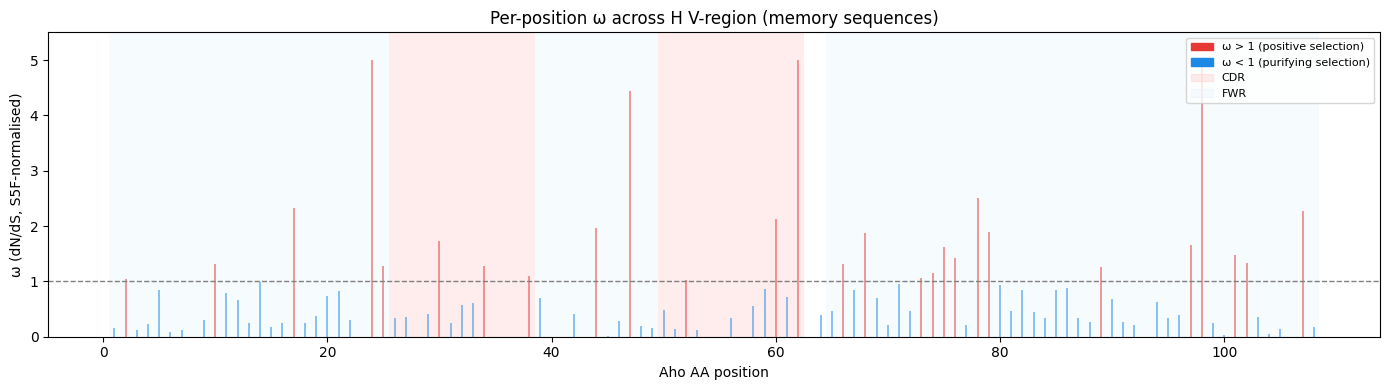

Saved.


In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Data ────────────────────────────────────────────────────────────────────
df = pl.read_csv(TABLES / "omega_per_position.csv")  # standalone-safe
df = df.filter(pl.col('omega').is_not_null())

plot_data = df.select(['aho_aa_pos', 'region', 'omega', 's5f_weight', 'n_valid'])
plot_data.write_csv(FIGURES / "fig_s1_omega_profile.csv")

x      = df['aho_aa_pos'].to_numpy()
y      = np.clip(df['omega'].to_numpy(), 0, 5)  # clip for display
regs   = df['region'].to_list()

# ── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

REGION_COLORS = {'CDR1':'#FFCCCC','CDR2':'#FFCCCC','FR1':'#E8F4FD','FR2':'#E8F4FD','FR3':'#E8F4FD'}
current_reg, reg_start = regs[0], x[0]
for i in range(1, len(regs)):
    if regs[i] != current_reg or i == len(regs) - 1:
        ax.axvspan(reg_start - 0.5, x[i-1] + 0.5, color=REGION_COLORS.get(current_reg,'#FFF'), alpha=0.35, lw=0)
        current_reg, reg_start = regs[i], x[i]

# Color by selection direction
colors = ['#E53935' if v > 1.0 else '#1E88E5' for v in y]
for xi, yi, ci in zip(x, y, colors):
    ax.vlines(xi, 0, yi, color=ci, alpha=0.6, lw=1.2)

ax.axhline(1.0, color='gray', linestyle='--', lw=1, label='ω=1 (neutral)')
ax.set_xlabel('Aho AA position')
ax.set_ylabel('ω (dN/dS, S5F-normalised)')
ax.set_title('Per-position ω across H V-region (memory sequences)')
ax.set_ylim(0, 5.5)

patches = [
    mpatches.Patch(color='#E53935', label='ω > 1 (positive selection)'),
    mpatches.Patch(color='#1E88E5', label='ω < 1 (purifying selection)'),
    mpatches.Patch(color='#FFCCCC', alpha=0.4, label='CDR'),
    mpatches.Patch(color='#E8F4FD', alpha=0.4, label='FWR'),
]
ax.legend(handles=patches, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / "fig_s1_omega_profile.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

shape: (5, 5)
┌────────┬────────────┬──────────────┬───────────┬─────────────┐
│ region ┆ mean_omega ┆ median_omega ┆ std_omega ┆ n_positions │
│ ---    ┆ ---        ┆ ---          ┆ ---       ┆ ---         │
│ str    ┆ f64        ┆ f64          ┆ f64       ┆ u32         │
╞════════╪════════════╪══════════════╪═══════════╪═════════════╡
│ CDR1   ┆ 0.736637   ┆ 0.567345     ┆ 0.515955  ┆ 9           │
│ FR1    ┆ 0.788945   ┆ 0.338368     ┆ 1.136165  ┆ 24          │
│ FR3    ┆ 0.916088   ┆ 0.682166     ┆ 0.990942  ┆ 43          │
│ FR2    ┆ 1.018464   ┆ 0.347366     ┆ 1.511457  ┆ 8           │
│ CDR2   ┆ 1.30117    ┆ 0.560047     ┆ 2.139814  ┆ 11          │
└────────┴────────────┴──────────────┴───────────┴─────────────┘


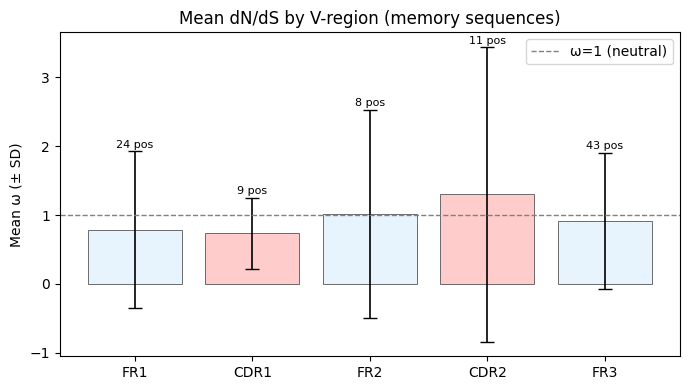

Saved.


In [11]:
import matplotlib.pyplot as plt

# ── Data: ω distribution by region ──────────────────────────────────────────
df = pl.read_csv(TABLES / "omega_per_position.csv").filter(pl.col('omega').is_not_null())

omega_by_region = (
    df.group_by('region')
    .agg([
        pl.col('omega').mean().alias('mean_omega'),
        pl.col('omega').median().alias('median_omega'),
        pl.col('omega').std().alias('std_omega'),
        pl.len().alias('n_positions'),
    ])
    .sort('mean_omega')
)
omega_by_region.write_csv(FIGURES / "fig_s1_omega_by_region.csv")
print(omega_by_region)

# ── Figure ──────────────────────────────────────────────────────────────────
REGION_ORDER = ['FR1','CDR1','FR2','CDR2','FR3']
reg_dict = {r['region']: r for r in omega_by_region.to_dicts()}
orderedREG = [r for r in REGION_ORDER if r in reg_dict]

means  = [reg_dict[r]['mean_omega']   for r in orderedREG]
stds   = [reg_dict[r]['std_omega']    for r in orderedREG]
npos   = [reg_dict[r]['n_positions']  for r in orderedREG]
colors = ['#FFCCCC' if 'CDR' in r else '#E8F4FD' for r in orderedREG]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(orderedREG, means, yerr=stds, capsize=5,
              color=colors, edgecolor='#555', linewidth=0.6,
              error_kw={'elinewidth': 1.2})
for i, (r, n, m) in enumerate(zip(orderedREG, npos, means)):
    ax.text(i, m + stds[i] + 0.02, f'{n} pos', ha='center', va='bottom', fontsize=8)
ax.axhline(1.0, color='gray', linestyle='--', lw=1, label='ω=1 (neutral)')
ax.set_ylabel('Mean ω (± SD)')
ax.set_title('Mean dN/dS by V-region (memory sequences)')
ax.legend()
plt.tight_layout()
plt.savefig(FIGURES / "fig_s1_omega_by_region.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## S1b — Per-germline ω (stratified dN/dS)

The pooled computation above uses a **consensus germline codon** across all ~1.5M memory sequences,
conflating multiple IGHV families at positions where they differ. Here we repeat the ω calculation
**stratified by IGHV gene**: each germline's own codon is used as the neutral-expectation codon,
removing cross-germline bias from the neutral R/S fractions.

Only germlines with ≥1000 memory sequences are scored (sufficient statistics for stable ω estimates).
The pooled results above remain valid as a summary but will differ from per-germline values at
positions where codon usage varies across families.

**Output:** `results/tables/omega_per_germline.parquet`

In [ ]:
# ── Map seq_name → v_gene:0 for memory sequences ────────────────────────────
# Column is 'v_gene:0' in aligned_master (colon-separated naming convention)
vgene_map = memory.select([KEY, 'v_gene:0'])

aligned_mem_vg = aligned_mem.join(
    vgene_map.with_columns(pl.col('v_gene:0').cast(pl.Utf8)),
    on=KEY, how='left'
)

# Germlines with >= 1000 memory sequences
vgene_counts = (
    aligned_mem_vg
    .group_by('v_gene:0')
    .agg(pl.len().alias('n'))
    .filter(pl.col('n') >= 1000)
    .sort('n', descending=True)
)
print(f"Germlines with ≥1000 memory sequences: {vgene_counts.height}")
print(vgene_counts.head(10))

# Convert v_gene:0 to numpy for fast row-index lookup
vgene_arr          = aligned_mem_vg['v_gene:0'].to_numpy()
eligible_germlines = vgene_counts['v_gene:0'].to_list()

print(f"\nRunning per-germline ω ({len(eligible_germlines)} germlines × {n_codons} codons)...")
t0 = time.time()

per_germ_records = []

for germ_name in eligible_germlines:
    idx    = np.where(vgene_arr == germ_name)[0]
    seq_g  = seq_HV[idx]
    germ_g = germ_HV[idx]

    for codon_i in range(n_codons):
        p0     = codon_i * 3
        nt_col = H_V_COLS_SEQ[p0]
        aho_aa = (int(nt_col[1:]) - 1) // 3 + 1
        region = col_to_region_H.get(nt_col, 'unknown')

        g = germ_g[:, p0:p0+3]
        s = seq_g[:,  p0:p0+3]

        valid = (np.all(g > 0, axis=1) & np.all(g != GAP, axis=1) &
                 np.all(s > 0, axis=1) & np.all(s != GAP, axis=1))
        n_valid = valid.sum()
        if n_valid < 10:
            continue

        has_mut  = valid & np.any(g != s, axis=1)
        g_aa     = translate_codon_array(g)
        s_aa     = translate_codon_array(s)
        valid_aa = (g_aa > 0) & (s_aa > 0) & (g_aa != ord('*')) & (s_aa != ord('*'))

        n_R_obs = int((has_mut & (g_aa != s_aa) & valid_aa).sum())
        n_S_obs = int((has_mut & (g_aa == s_aa) & valid_aa).sum())

        # Germline-specific consensus codon (sample up to 2000 valid rows)
        valid_idx = np.where(valid)[0]
        g_sample  = g[valid_idx[:2000]]
        codon_counts_g = defaultdict(int)
        for row_g in g_sample:
            nt_str = ''.join(INT_TO_NT.get(int(x), '?') for x in row_g)
            if '?' not in nt_str:
                codon_counts_g[nt_str] += 1
        if not codon_counts_g:
            continue
        consensus_codon = max(codon_counts_g, key=codon_counts_g.get)

        e_dn_frac, e_ds_frac = expected_rs_fractions(consensus_codon)
        if np.isnan(e_dn_frac) or e_dn_frac == 0 or e_ds_frac == 0:
            omega = None
        else:
            dN_obs = n_R_obs / n_valid
            dS_obs = n_S_obs / n_valid
            if dS_obs == 0:
                dS_obs = 0.5 / n_valid
            omega = float((dN_obs * e_ds_frac) / (dS_obs * e_dn_frac))

        per_germ_records.append({
            'v_gene':          germ_name,
            'nt_col':          nt_col,
            'aho_aa_pos':      aho_aa,
            'region':          region,
            'consensus_codon': consensus_codon,
            'n_valid':         int(n_valid),
            'n_R_obs':         n_R_obs,
            'n_S_obs':         n_S_obs,
            'dN_obs':          float(n_R_obs / n_valid),
            'dS_obs':          float(n_S_obs / n_valid),
            'e_dN_frac':       float(e_dn_frac) if not np.isnan(e_dn_frac) else None,
            'e_dS_frac':       float(e_ds_frac) if not np.isnan(e_ds_frac) else None,
            's5f_weight':      float(codon_s5f[codon_i]),
            'omega':           omega,
        })

omega_germ_df = pl.DataFrame(per_germ_records)
print(f"Done in {time.time()-t0:.1f}s — {omega_germ_df.height:,} records")

# Save
OMEGA_GERM_FILE = TABLES / 'omega_per_germline.parquet'
omega_germ_df.write_parquet(OMEGA_GERM_FILE)
omega_germ_df.write_csv(TABLES / 'omega_per_germline.csv')
print(f"Saved → {OMEGA_GERM_FILE}")

# ── Compare pooled vs per-germline median ω by region ───────────────────────
pooled_sum = (
    pl.read_csv(TABLES / 'omega_per_position.csv')
    .filter(pl.col('omega').is_not_null())
    .group_by('region')
    .agg(pl.col('omega').median().alias('pooled_median'))
)
pergerm_sum = (
    omega_germ_df.filter(pl.col('omega').is_not_null())
    .group_by('region')
    .agg(
        pl.col('omega').median().alias('per_germ_median'),
        pl.col('omega').mean().alias('per_germ_mean'),
        pl.len().alias('n_records'),
    )
)
print("\nPooled vs per-germline median ω by region:")
print(pooled_sum.join(pergerm_sum, on='region').sort('pooled_median'))

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Per-germline ω: boxplot by region + top germlines by CDR2 ω ─────────────
df_pg = pl.read_csv(TABLES / 'omega_per_germline.csv').filter(pl.col('omega').is_not_null())
df_pg = df_pg.with_columns(pl.col('omega').clip(upper_bound=5.0))  # clip outliers for display

REGION_ORDER  = ['FR1', 'CDR1', 'FR2', 'CDR2', 'FR3']
REGION_COLORS = {'CDR1': '#FFCCCC', 'CDR2': '#FFCCCC',
                 'FR1': '#E8F4FD', 'FR2': '#E8F4FD', 'FR3': '#E8F4FD'}

box_data = [df_pg.filter(pl.col('region') == r)['omega'].to_numpy()
            for r in REGION_ORDER]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-region boxplot (distribution across all germline × position records)
ax = axes[0]
bp = ax.boxplot(box_data, labels=REGION_ORDER, patch_artist=True,
                medianprops={'color': '#333', 'linewidth': 2},
                flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.4})
for patch, region in zip(bp['boxes'], REGION_ORDER):
    patch.set_facecolor(REGION_COLORS[region])
    patch.set_alpha(0.7)
ax.axhline(1.0, color='gray', linestyle='--', lw=1, label='ω=1 (neutral)')
ax.set_ylabel('ω (dN/dS, S5F-normalised, clipped at 5)')
ax.set_title('Per-germline ω distribution by V-region\n(each point = one germline × position)')
ax.legend(fontsize=8)

# Right: top germlines by mean CDR2 ω (≥500 sequences at scored CDR2 positions)
ax2 = axes[1]
cdr2_pg = (
    df_pg.filter(pl.col('region') == 'CDR2')
    .group_by('v_gene')
    .agg([
        pl.col('omega').mean().alias('mean_omega_CDR2'),
        pl.col('n_valid').sum().alias('n_total'),
    ])
    .filter(pl.col('n_total') >= 500)
    .sort('mean_omega_CDR2', descending=True)
)
top_n  = min(20, cdr2_pg.height)
genes  = cdr2_pg['v_gene'].to_list()[:top_n]
omegas = cdr2_pg['mean_omega_CDR2'].to_numpy()[:top_n]

colors2 = ['#E53935' if v > 1.0 else '#1E88E5' for v in omegas]
ax2.barh(range(top_n), omegas[::-1], color=colors2[::-1], alpha=0.8)
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(genes[::-1], fontsize=8)
ax2.axvline(1.0, color='gray', linestyle='--', lw=1)
ax2.set_xlabel('Mean CDR2 ω per germline')
ax2.set_title(f'Top {top_n} germlines by mean CDR2 ω')

plt.tight_layout()
plt.savefig(FIGURES / 'fig_s1b_omega_per_germline.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## S2 — Forbidden Mutations (Φ_S filter)

For each V-region codon position, compare the **expected** per-sequence mutation frequency
(derived from S5F mutability) to the **observed** frequency in memory sequences.

**Formula:**
```
phi_S_filter[i] = log( expected_per_seq[i] / (observed_freq[i] + ε) )
```

where:
- `expected_per_seq[i] = 1 − (1 − p_event[i])^mean_V_mut`
  — fraction of sequences expected to carry ≥1 mutation at position i under neutral SHM
- `p_event[i] = s5f_weight[i] / Σ s5f_weights`
  — per-SHM-event probability of a mutation landing at codon i (from S5F profile)
- `mean_V_mut` — mean V-region (FR1–CDR2) mutation count per memory sequence, estimated from data
- `observed_freq[i] = (n_R_obs[i] + n_S_obs[i]) / n_valid[i]`
  — fraction of memory sequences with any mutation at position i

**Interpretation:**
- `phi_S_filter > 0` → observed < expected → SHM generates mutations here but selection removes them → **structural constraint active**
- `phi_S_filter < 0` → observed > expected → positive selection drives mutations here → **affinity-driven position**

**Note:** All codon positions are included (including Met/Trp where ω is undefined)
for correct S5F budget normalisation.

In [ ]:
epsilon = 1e-6

# Use ALL rows (102 total, including Met/Trp with null omega) so the S5F budget denominator
# is correct — Met/Trp have zero synonymous capacity but still consume mutational budget.
omega_data_all = pl.read_csv(TABLES / "omega_per_position.csv")
total_s5f = omega_data_all['s5f_weight'].sum()

# Estimate mean V-region mutations per memory sequence from observed counts.
# total_mut_events = sum of all R+S mutations observed across the dataset;
# dividing by mean n_valid gives average mutations per sequence.
total_mut_events = (omega_data_all['n_R_obs'] + omega_data_all['n_S_obs']).sum()
mean_n_valid     = omega_data_all['n_valid'].mean()
mean_V_mut       = total_mut_events / mean_n_valid
print(f"Total S5F weight (proportional to mutability budget): {total_s5f:.4f}")
print(f"Estimated mean V-region mutations per memory sequence: {mean_V_mut:.2f}")

# CORRECTED phi_S formula
# ─────────────────────────────────────────────────────────────────────────────
# BUG in previous version:
#   expected_freq  = s5f_weight / total_s5f          ← per-SHM-event probability (~0.002–0.06)
#   observed_freq  = (n_R+n_S) / n_valid             ← per-sequence rate          (~0.003–0.60)
# These are on completely different scales (off by ~mean_V_mut ≈ 8×).
#
# FIX: convert per-event probability to per-sequence probability assuming
# Poisson/binomial sampling over mean_V_mut mutation events:
#   p_event    = s5f_weight / total_s5f
#   p_seq      = 1 - (1 - p_event)^mean_V_mut
#   phi_S      = log(p_seq / (obs_freq + epsilon))
#
# Negative phi_S → position mutated LESS than expected → structural/functional constraint.
# Positive phi_S → position mutated MORE than expected → possible positive selection.
# ─────────────────────────────────────────────────────────────────────────────

forbidden_records = []
for row in omega_data_all.to_dicts():
    if row['n_valid'] is None or row['n_valid'] == 0:
        continue
    p_event  = row['s5f_weight'] / total_s5f
    exp_seq  = 1.0 - (1.0 - p_event) ** mean_V_mut   # binomial complement
    obs_freq = (row['n_R_obs'] + row['n_S_obs']) / row['n_valid']
    phi_s    = np.log(exp_seq / (obs_freq + epsilon))
    forbidden_records.append({
        'nt_col':             row['nt_col'],
        'aho_aa_pos':         row['aho_aa_pos'],
        'region':             row['region'],
        'expected_per_event': float(p_event),
        'expected_per_seq':   float(exp_seq),
        'observed_freq':      float(obs_freq),
        'phi_S_filter':       float(phi_s),
        'omega':              row['omega'],
    })

forbidden_df = (
    pl.DataFrame(forbidden_records)
    .sort('phi_S_filter')              # ascending: most negative = most constrained
)

print(f"\nTop 10 most constrained positions (most negative phi_S):")
print(forbidden_df.select(['nt_col','aho_aa_pos','region',
                            'expected_per_seq','observed_freq','phi_S_filter','omega']).head(10))
print(f"\nTop 5 most enriched positions (least constrained / positive selection):")
print(forbidden_df.select(['nt_col','aho_aa_pos','region',
                            'expected_per_seq','observed_freq','phi_S_filter','omega']).tail(5))

forbidden_df.write_csv(TABLES / "forbidden_mutations.csv")

In [13]:
forbidden_df.write_parquet(FORBID_FILE)
forbidden_df.write_csv(TABLES / "forbidden_mutations.csv")
print(f"Saved → {FORBID_FILE}")

Saved → /home/jovyan/shared/Benjamin/LineageAtlas/pairplex_paper/results/tables/forbidden_mutations.parquet


In [ ]:
import matplotlib.pyplot as plt

# ── Data ────────────────────────────────────────────────────────────────────
df = pl.read_csv(TABLES / "forbidden_mutations.csv")  # standalone-safe

plot_data = df.select(['aho_aa_pos', 'region', 'expected_per_seq', 'observed_freq', 'phi_S_filter'])
plot_data.write_csv(FIGURES / "fig_s2_forbidden_scatter.csv")

# ── Figure ──────────────────────────────────────────────────────────────────
REGION_COLOR = {'CDR1':'#E53935','CDR2':'#E53935','FR1':'#1E88E5','FR2':'#1E88E5','FR3':'#1E88E5'}

x    = df['expected_per_seq'].to_numpy()
y    = df['observed_freq'].to_numpy()
regs = df['region'].to_list()
colors = [REGION_COLOR.get(r, '#888') for r in regs]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(x, y, c=colors, s=15, alpha=0.7, linewidths=0)

# Diagonal = expected == observed
lim = max(x.max(), y.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', lw=0.8, label='Expected = Observed')

import matplotlib.patches as mpatches
patches = [mpatches.Patch(color='#E53935', label='CDR'), mpatches.Patch(color='#1E88E5', label='FWR')]
ax.legend(handles=patches)
ax.set_xlabel('Expected mutation frequency per sequence (S5F-corrected)')
ax.set_ylabel('Observed mutation frequency (memory)')
ax.set_title('Forbidden mutations: expected vs observed per position\n(points below diagonal = structurally constrained)')
plt.tight_layout()
plt.savefig(FIGURES / "fig_s2_forbidden_scatter.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

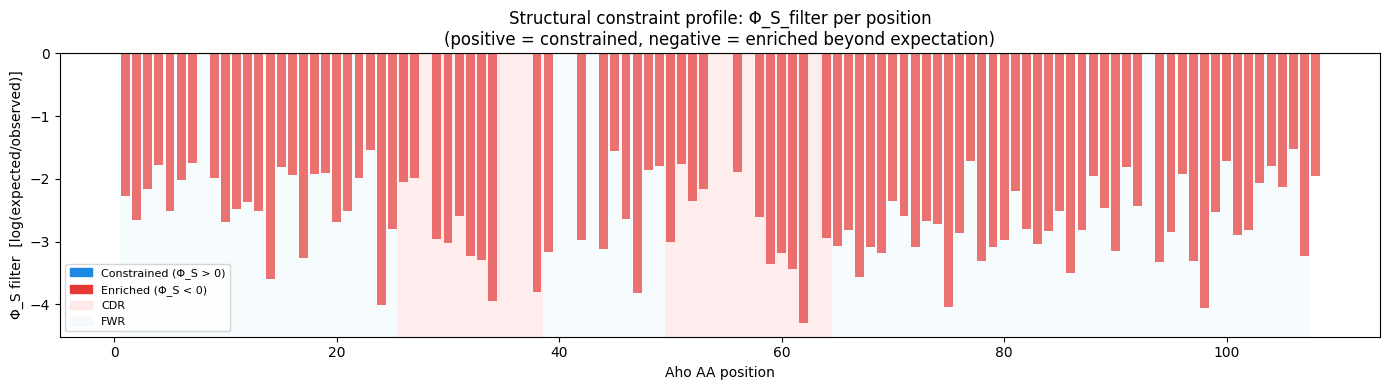

Saved.


In [15]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Data ────────────────────────────────────────────────────────────────────
df = pl.read_csv(TABLES / "forbidden_mutations.csv").sort('aho_aa_pos')  # standalone-safe

plot_data = df.select(['aho_aa_pos', 'region', 'phi_S_filter'])
plot_data.write_csv(FIGURES / "fig_s2_phi_s_profile.csv")

x    = df['aho_aa_pos'].to_numpy()
y    = df['phi_S_filter'].to_numpy()
regs = df['region'].to_list()

# ── Figure ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))

REGION_COLORS = {'CDR1':'#FFCCCC','CDR2':'#FFCCCC','FR1':'#E8F4FD','FR2':'#E8F4FD','FR3':'#E8F4FD'}
current_reg, reg_start = regs[0], x[0]
for i in range(1, len(regs)):
    if regs[i] != current_reg or i == len(regs)-1:
        ax.axvspan(reg_start-0.5, x[i-1]+0.5, color=REGION_COLORS.get(current_reg,'#FFF'), alpha=0.35, lw=0)
        current_reg, reg_start = regs[i], x[i]

ax.bar(x, y, color=['#1E88E5' if v > 0 else '#E53935' for v in y], alpha=0.7, width=0.8, edgecolor='none')
ax.axhline(0, color='gray', lw=0.8)
ax.set_xlabel('Aho AA position')
ax.set_ylabel('Φ_S filter  [log(expected/observed)]')
ax.set_title('Structural constraint profile: Φ_S_filter per position\n(positive = constrained, negative = enriched beyond expectation)')

patches = [
    mpatches.Patch(color='#1E88E5', label='Constrained (Φ_S > 0)'),
    mpatches.Patch(color='#E53935', label='Enriched (Φ_S < 0)'),
    mpatches.Patch(color='#FFCCCC', alpha=0.4, label='CDR'),
    mpatches.Patch(color='#E8F4FD', alpha=0.4, label='FWR'),
]
ax.legend(handles=patches, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES / "fig_s2_phi_s_profile.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## S3 — VH/VL Vernier Co-evolution (Mutation Co-occurrence MI)

Vernier zone positions mediate VH/VL packing geometry and are hypothesised to co-evolve during
germinal centre (GC) affinity maturation. We test this using **mutation co-occurrence mutual
information** on binary somatic hypermutation states.

**Why binary mutation state, not AA identity?**  
AA identity at Vernier positions is dominated by germline gene usage: different IGHV/IGKV/IGLV
families encode fixed distinct amino acids at these positions. Computing MI on raw AA identity
would capture germline gene co-selection (VH-VL pairing preferences at the naive repertoire
level), not somatic co-evolution within GC reactions.

By encoding each position as `mutated = (seq_AA ≠ germ_AA)`, we isolate the GC-driven signal:
positions that tend to be *co-mutated* (or co-unmutated) across clones share coupled
selection pressure during affinity maturation.

**For each VH position i × VL position j:**
- `mut_H[i]` ∈ {0,1}: any replacement AA mutation at VH Vernier position i
- `mut_L[j]` ∈ {0,1}: any replacement AA mutation at VL Vernier position j
- `MI(i,j)` = mutual information on the 2×2 co-occurrence table (Miller-Madow corrected)
- `phi(i,j)` = Matthews correlation coefficient (φ) = (p11·p00 − p10·p01) / √(marginal products)

**VH Vernier positions (Aho AA):** 2, 47, 48, 67, 69, 71, 78, 93, 94  
**VL Vernier positions (Aho AA):** 2, 36, 46, 48, 49, 64, 66, 68, 71

In [16]:
# Vernier zone Aho AA positions → AA columns in the master table
# The master table has iggnition-aligned nt columns; for AA-level co-variation
# we extract the amino acid from the sequence string (sequence_aa:0 / :1)
# OR we translate directly from the aligned nt codons.
# We use the nt arrays for consistency with the rest of the pipeline.

VERNIER_H_AA = [2, 47, 48, 67, 69, 71, 78, 93, 94]
VERNIER_L_AA = [2, 36, 46, 48, 49, 64, 66, 68, 71]

def aa_nt_cols(chain: str, aho_aa: int) -> list[str]:
    """Return the 3 nt column names for Aho AA position."""
    start = (aho_aa - 1) * 3 + 1
    return [f"{chain}{i}" for i in range(start, start + 3)]

V_H_NT = [aa_nt_cols('H', aa) for aa in VERNIER_H_AA]
V_L_NT = [aa_nt_cols('L', aa) for aa in VERNIER_L_AA]

# Flatten and filter to columns present in alignment
all_V_H = [c for triplet in V_H_NT for c in triplet]
all_V_L = [c for triplet in V_L_NT for c in triplet]

present = set(aligned_mem.columns)
all_V_H = [c for c in all_V_H if c in present]
all_V_L = [c for c in all_V_L if c in present]

print(f"VH Vernier nt cols: {len(all_V_H)} ({len(all_V_H)//3} positions)")
print(f"VL Vernier nt cols: {len(all_V_L)} ({len(all_V_L)//3} positions)")

VH Vernier nt cols: 27 (9 positions)
VL Vernier nt cols: 27 (9 positions)


In [ ]:
def extract_mutation_state(aligned, nt_triplet_cols):
    """
    Return (mutated_bool, valid_bool) arrays of length N.

    mutated_bool[n] = True  iff sequence n carries a replacement AA mutation
                             at this codon relative to its germline.
    valid_bool[n]   = True  iff both the sequence and germline codons are non-null,
                             non-gap, and translate to a non-stop non-unknown AA.

    We use aligned_mem which has both seq and germ columns (suffix '_germ').
    """
    seq_cols  = [c for c in nt_triplet_cols if c in set(aligned.columns)]
    germ_cols = [f"{c}_germ" for c in seq_cols if f"{c}_germ" in set(aligned.columns)]

    if len(seq_cols) < 3 or len(germ_cols) < 3:
        N = aligned.height
        return np.zeros(N, dtype=bool), np.zeros(N, dtype=bool)

    s = aligned.select(seq_cols[:3]).fill_null(0).to_numpy().astype(np.int32)
    g = aligned.select(germ_cols[:3]).fill_null(0).to_numpy().astype(np.int32)

    valid = (
        np.all(s > 0, axis=1) & np.all(s != GAP, axis=1) &
        np.all(g > 0, axis=1) & np.all(g != GAP, axis=1)
    )
    s_aa = translate_codon_array(s)
    g_aa = translate_codon_array(g)

    # Exclude stop codons and untranslatable codons
    valid = valid & (s_aa > 0) & (g_aa > 0) & (s_aa != ord('*')) & (g_aa != ord('*'))

    # Binary mutation state: replacement (AA changed)
    mutated = valid & (s_aa != g_aa)
    return mutated, valid


# ── Collect binary mutation state arrays for all Vernier positions ────────────
print("Extracting binary mutation states at Vernier positions...")

# VH
vh_mut_arrays = []
for aa_pos, triplet in zip(VERNIER_H_AA, V_H_NT):
    mutated, valid = extract_mutation_state(aligned_mem, triplet)
    n_valid  = int(valid.sum())
    n_mutated = int(mutated.sum())
    mut_rate  = n_mutated / n_valid if n_valid > 0 else 0.0
    print(f"  VH{aa_pos:3d}: n_valid={n_valid:>8,}  n_mutated={n_mutated:>7,}  mut_rate={mut_rate:.4f}")
    if n_valid >= 100:
        vh_mut_arrays.append((aa_pos, mutated, valid))
    else:
        print(f"    → SKIPPED (n_valid < 100)")

print()
# VL
vl_mut_arrays = []
for aa_pos, triplet in zip(VERNIER_L_AA, V_L_NT):
    mutated, valid = extract_mutation_state(aligned_mem, triplet)
    n_valid  = int(valid.sum())
    n_mutated = int(mutated.sum())
    mut_rate  = n_mutated / n_valid if n_valid > 0 else 0.0
    print(f"  VL{aa_pos:3d}: n_valid={n_valid:>8,}  n_mutated={n_mutated:>7,}  mut_rate={mut_rate:.4f}")
    if n_valid >= 100:
        vl_mut_arrays.append((aa_pos, mutated, valid))
    else:
        print(f"    → SKIPPED (n_valid < 100)")

print(f"\nVH positions for MI: {[p for p,_,_ in vh_mut_arrays]}")
print(f"VL positions for MI: {[p for p,_,_ in vl_mut_arrays]}")

In [ ]:
def mi_binary_mm(mut_h: np.ndarray, valid_h: np.ndarray,
                 mut_l: np.ndarray, valid_l: np.ndarray):
    """
    Mutual information + phi coefficient on 2×2 binary co-occurrence table.

    Both input arrays are length-N booleans.
    mut_x[n]   = True iff sequence n is mutated at position x
    valid_x[n] = True iff position x is scoreable for sequence n

    Returns dict with:
      MI_corrected  — Miller-Madow bias-corrected MI (bits)
      phi_coef      — Matthews correlation coefficient (range -1 to +1)
      n_valid       — number of sequences valid at both positions
      p_mut_H       — marginal mutation rate at VH position
      p_mut_L       — marginal mutation rate at VL position
      p11           — fraction of sequences mutated at BOTH positions
      p11_exp       — expected p11 under independence (p_mut_H × p_mut_L)
    """
    both_valid = valid_h & valid_l
    N = int(both_valid.sum())
    if N < 50:
        return {'MI_corrected': np.nan, 'phi_coef': np.nan, 'n_valid': N,
                'p_mut_H': np.nan, 'p_mut_L': np.nan, 'p11': np.nan, 'p11_exp': np.nan}

    mh = mut_h[both_valid].astype(np.int8)
    ml = mut_l[both_valid].astype(np.int8)

    # 2×2 counts: (H_state, L_state) where state ∈ {0,1}
    n11 = int(( mh &  ml).sum())  # both mutated
    n10 = int(( mh & ~ml.astype(bool)).sum())  # H mutated, L not
    n01 = int((~mh.astype(bool) &  ml).sum())  # L mutated, H not
    n00 = int((~mh.astype(bool) & ~ml.astype(bool)).sum())  # neither mutated

    cells = {(1,1): n11, (1,0): n10, (0,1): n01, (0,0): n00}
    nH1, nH0 = n11 + n10, n01 + n00   # marginal H
    nL1, nL0 = n11 + n01, n10 + n00   # marginal L

    p_mut_H = nH1 / N
    p_mut_L = nL1 / N
    p11     = n11 / N
    p11_exp = p_mut_H * p_mut_L

    # MI
    MI = 0.0
    n_nonzero = 0
    for (hv, lv), cnt in cells.items():
        if cnt == 0:
            continue
        n_nonzero += 1
        p_joint = cnt / N
        p_marg_h = (nH1 if hv == 1 else nH0) / N
        p_marg_l = (nL1 if lv == 1 else nL0) / N
        if p_marg_h > 0 and p_marg_l > 0:
            MI += p_joint * np.log2(p_joint / (p_marg_h * p_marg_l))

    # Miller-Madow correction: (n_nonzero_cells - 1) / (2N * log(2))
    # (MI was computed in bits, correction is also in bits)
    MI_corrected = max(MI - (n_nonzero - 1) / (2 * N), 0.0)

    # Phi coefficient (MCC for 2×2)
    denom = np.sqrt(float(nH1) * float(nH0) * float(nL1) * float(nL0))
    phi = (n11 * n00 - n10 * n01) / denom if denom > 0 else 0.0

    return {
        'MI_corrected': float(MI_corrected),
        'phi_coef':     float(phi),
        'n_valid':      N,
        'p_mut_H':      float(p_mut_H),
        'p_mut_L':      float(p_mut_L),
        'p11':          float(p11),
        'p11_exp':      float(p11_exp),
    }


# ── Pairwise VH × VL mutation co-occurrence MI ───────────────────────────────
print("Computing pairwise mutation co-occurrence MI (binary)...")
t0 = time.time()

mi_records = []
for h_pos, h_mut, h_valid in vh_mut_arrays:
    for l_pos, l_mut, l_valid in vl_mut_arrays:
        res = mi_binary_mm(h_mut, h_valid, l_mut, l_valid)
        mi_records.append({
            'VH_aa_pos':    h_pos,
            'VL_aa_pos':    l_pos,
            'MI_corrected': res['MI_corrected'] if not np.isnan(res['MI_corrected']) else None,
            'phi_coef':     res['phi_coef']     if not np.isnan(res['phi_coef'])     else None,
            'n_valid':      res['n_valid'],
            'p_mut_H':      res['p_mut_H']      if not np.isnan(res['p_mut_H'])      else None,
            'p_mut_L':      res['p_mut_L']      if not np.isnan(res['p_mut_L'])      else None,
            'p11':          res['p11']           if not np.isnan(res['p11'])          else None,
            'p11_exp':      res['p11_exp']       if not np.isnan(res['p11_exp'])      else None,
        })

mi_df = pl.DataFrame(mi_records)
print(f"Done in {time.time()-t0:.1f}s — {mi_df.height} pairs")

# Top pairs by phi coefficient
valid_mi = mi_df.filter(pl.col('phi_coef').is_not_null()).sort('phi_coef', descending=True)
print(f"\nTop 10 pairs by phi coefficient (positive co-mutation):")
print(valid_mi.select(['VH_aa_pos','VL_aa_pos','phi_coef','MI_corrected',
                        'p_mut_H','p_mut_L','p11','p11_exp','n_valid']).head(10))
print(f"\nBottom 5 pairs by phi coefficient (anti-correlated):")
print(valid_mi.select(['VH_aa_pos','VL_aa_pos','phi_coef','MI_corrected',
                        'p_mut_H','p_mut_L','p11','p11_exp','n_valid']).tail(5))

In [ ]:
mi_df.write_csv(MI_FILE)
print(f"Saved → {MI_FILE}")
print(f"Columns: {mi_df.columns}")
print(f"Pairs with valid MI: {mi_df.filter(pl.col('MI_corrected').is_not_null()).height}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ── Data ────────────────────────────────────────────────────────────────────
df = pl.read_csv(MI_FILE)  # standalone-safe

plot_data = df.select(['VH_aa_pos', 'VL_aa_pos', 'MI_corrected', 'phi_coef',
                        'p_mut_H', 'p_mut_L', 'n_valid'])
plot_data.write_csv(FIGURES / "fig_s3_mi_heatmap.csv")

# Pivot to matrices
vh_positions = sorted(df['VH_aa_pos'].unique().to_list())
vl_positions = sorted(df['VL_aa_pos'].unique().to_list())
df_dict = {(r['VH_aa_pos'], r['VL_aa_pos']): r for r in df.to_dicts()}

mi_matrix  = np.zeros((len(vh_positions), len(vl_positions)))
phi_matrix = np.zeros((len(vh_positions), len(vl_positions)))
nval_matrix = np.zeros((len(vh_positions), len(vl_positions)))

for i, vh in enumerate(vh_positions):
    for j, vl in enumerate(vl_positions):
        rec = df_dict.get((vh, vl), {})
        mi_val  = rec.get('MI_corrected')
        phi_val = rec.get('phi_coef')
        mi_matrix[i, j]   = mi_val  if mi_val  is not None else 0.0
        phi_matrix[i, j]  = phi_val if phi_val is not None else 0.0
        nval_matrix[i, j] = rec.get('n_valid', 0) or 0

vh_labels = [f"VH{p}" for p in vh_positions]
vl_labels = [f"VL{p}" for p in vl_positions]

# ── Per-position mutation rates (from first valid pairing) ──────────────────
mut_rate_H = {}
mut_rate_L = {}
for i, vh in enumerate(vh_positions):
    for j, vl in enumerate(vl_positions):
        rec = df_dict.get((vh, vl), {})
        if rec.get('p_mut_H') is not None and vh not in mut_rate_H:
            mut_rate_H[vh] = rec['p_mut_H']
        if rec.get('p_mut_L') is not None and vl not in mut_rate_L:
            mut_rate_L[vl] = rec['p_mut_L']

# ── Figure: 2-panel heatmaps ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, matrix, title, cmap, vcenter in [
    (axes[0], mi_matrix,  'Mutation co-occurrence MI\n(bits, Miller-Madow)',    'YlOrRd',  None),
    (axes[1], phi_matrix, 'Phi coefficient (Matthews CC)\nof mutation co-occurrence', 'RdBu_r', 0.0),
]:
    if vcenter is not None:
        norm = mcolors.TwoSlopeNorm(vcenter=vcenter,
                                     vmin=phi_matrix.min(), vmax=phi_matrix.max())
        im = ax.imshow(matrix, cmap=cmap, norm=norm, aspect='auto')
    else:
        im = ax.imshow(matrix, cmap=cmap, aspect='auto')

    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    ax.set_xticks(range(len(vl_positions)))
    ax.set_xticklabels(vl_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticks(range(len(vh_positions)))
    ax.set_yticklabels(vh_labels, fontsize=9)

    # Annotate cells with n_valid = 0 (missing positions)
    for i in range(len(vh_positions)):
        for j in range(len(vl_positions)):
            if nval_matrix[i, j] == 0:
                ax.text(j, i, '✕', ha='center', va='center', fontsize=8, color='gray')

    ax.set_title(title)

# Add mutation rate marginal bars
ax = axes[0]
for i, vh in enumerate(vh_positions):
    r = mut_rate_H.get(vh, 0)
    ax.text(-0.6, i, f'{r:.3f}', ha='right', va='center', fontsize=7, color='#555')
ax.text(-0.6, -0.8, 'mut_r', ha='right', va='center', fontsize=7, color='#888')

for j, vl in enumerate(vl_positions):
    r = mut_rate_L.get(vl, 0)
    ax.text(j, len(vh_positions) + 0.3, f'{r:.3f}', ha='center', va='bottom',
            fontsize=7, color='#555', rotation=45)

fig.suptitle('VH–VL Vernier zone mutation co-occurrence\n(binary SHM state, paired memory sequences)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "fig_s3_mi_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

## Step 2 Summary

| Calculation | Output table | Output figure(s) |
|-------------|-------------|------------------|
| S1: ω per position (pooled) | `omega_per_position.csv` | `fig_s1_omega_profile.png`, `fig_s1_omega_by_region.png` |
| S1b: ω per germline (stratified) | `omega_per_germline.parquet` | `fig_s1b_omega_per_germline.png` |
| S2: Forbidden mutations / Φ_S filter | `forbidden_mutations.csv` | `fig_s2_forbidden_scatter.png`, `fig_s2_phi_s_profile.png` |
| S3: VH/VL Vernier mutation co-occurrence | `vh_vl_mutual_information.csv` | `fig_s3_mi_heatmap.png` |

**Key corrections applied:**

**S2 (Φ_S):** Previous version compared per-SHM-event probability to per-sequence observed rate
(scale mismatch ~8×, causing all Φ_S < 0). Fixed by converting to per-sequence probability:
`expected_per_seq = 1 − (1 − p_event)^mean_V_mut`.

**S3 (MI):** Previous version computed MI on raw AA identity, dominated by germline gene
co-selection. Redesigned to use binary mutation state `(seq_AA ≠ germ_AA)` to isolate
somatic co-evolution signal within GC reactions. Added phi coefficient (Matthews CC) for
interpretable effect size.

**Interpretation for Φ_S:**
- `ω_i < 1` → purifying selection → `Φ_S(i) = −log(ω_i) > 0`
- `phi_S_filter > 0` → generated mutations are removed → structural constraint
- `phi_S_filter < 0` → enriched beyond expectation → positive selection driving mutations

**Interpretation for S3:**
- `phi_coef > 0` → positions tend to be co-mutated → coupled positive selection
- `phi_coef < 0` → anti-correlated mutations → possibly compensatory / antagonistic
- `phi_coef ≈ 0`, low MI → positions mutate independently within GC reactions

**Next step:** `03_phi_affinity.ipynb` — Affinity deficit Φ_A (A1–A3)